### IMPORTING LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

### LOADING THE DATASET

In [3]:
df = pd.read_csv("CC GENERAL.csv")  
print(df.shape)
print(df.head())

(8950, 18)
  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.00

### DATA CLEANING

In [4]:
df.drop("CUST_ID", axis=1, inplace=True)

df = df.fillna(df.median())

In [5]:
print(df.isnull().sum().sum())

0


### EDA - Eploratory Data Analysis

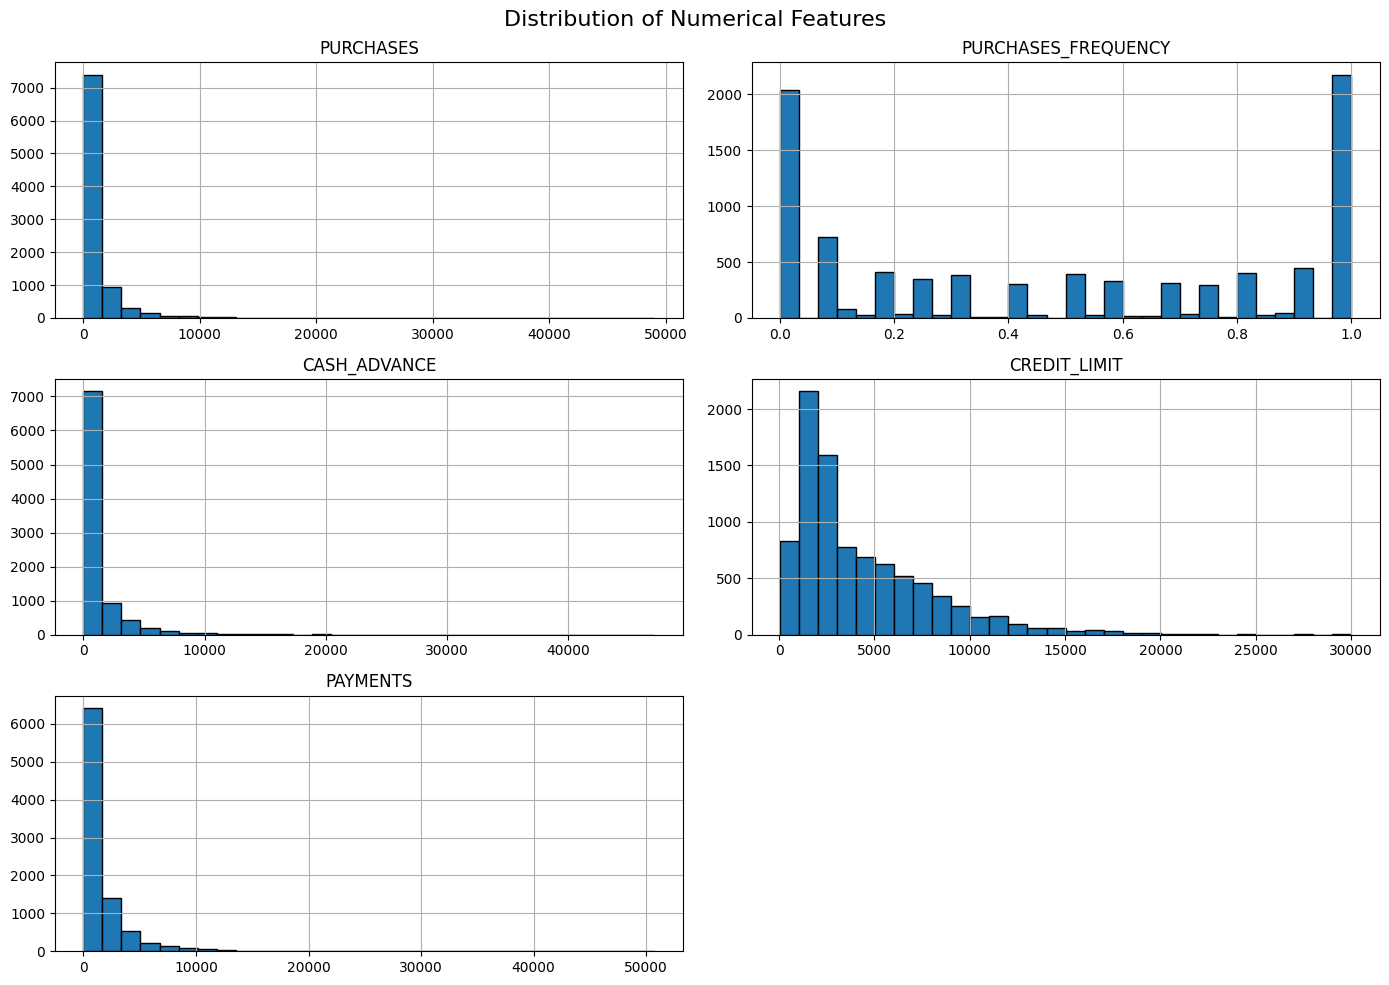

In [6]:
#Histograms
eda_features = [
    "PURCHASES",
    "PURCHASES_FREQUENCY",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS"
]

df[eda_features].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

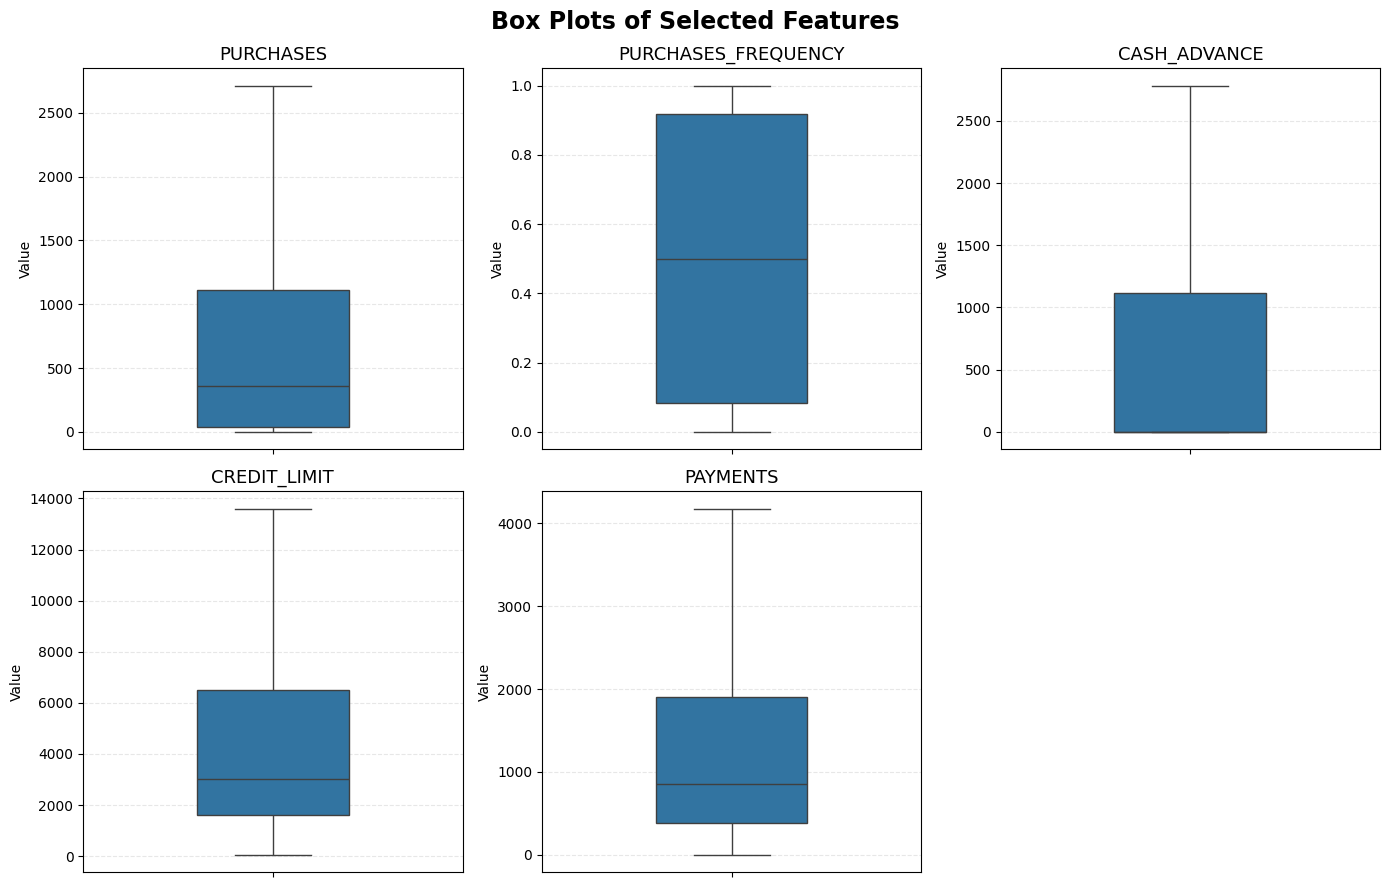

In [7]:
features = [
    "PURCHASES",
    "PURCHASES_FREQUENCY",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes = axes.flatten()

for i, feature in enumerate(features):

    sns.boxplot(
        y=df[feature],
        ax=axes[i],
        width=0.4,
        showfliers=False
    )

    axes[i].set_title(feature, fontsize=13)
    axes[i].set_ylabel("Value")
    axes[i].grid(axis="y", linestyle="--", alpha=0.3)

# Remove empty 6th subplot
fig.delaxes(axes[5])

fig.suptitle(
    "Box Plots of Selected Features",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

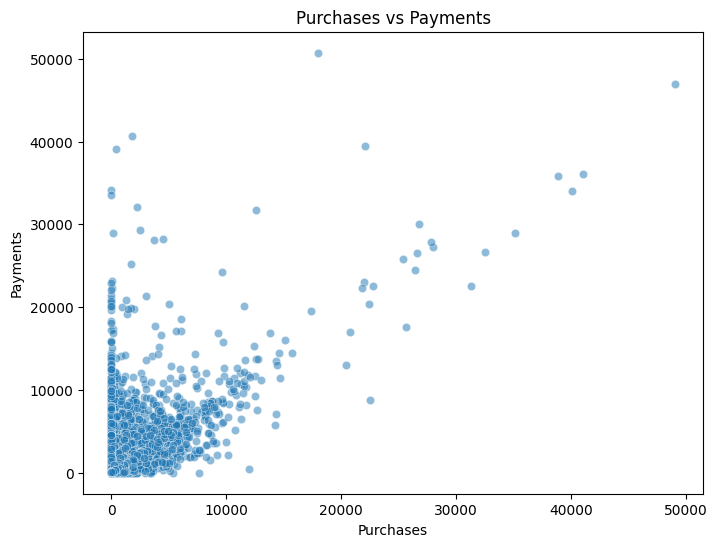

In [8]:
# Scatter plots
## Purchases vs Payments
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="PURCHASES",
    y="PAYMENTS",
    alpha=0.5
)

plt.title("Purchases vs Payments")
plt.xlabel("Purchases")
plt.ylabel("Payments")
plt.show()

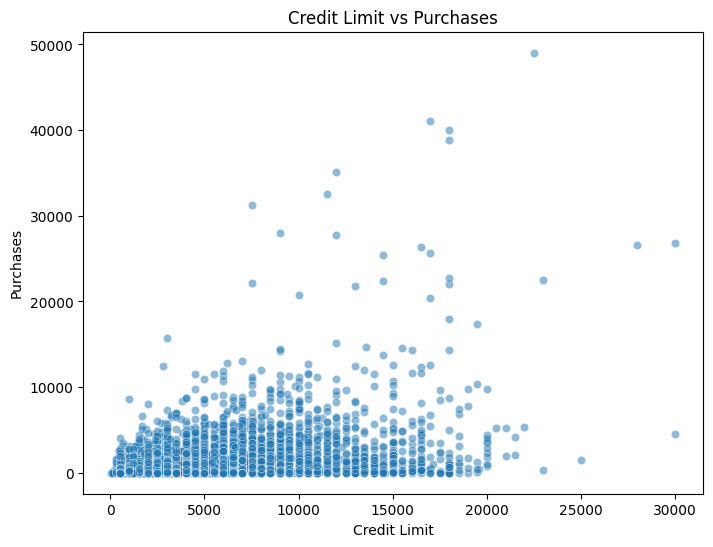

In [9]:
#Credit Limit vs Purchases
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="CREDIT_LIMIT",
    y="PURCHASES",
    alpha=0.5
)

plt.title("Credit Limit vs Purchases")
plt.xlabel("Credit Limit")
plt.ylabel("Purchases")
plt.show()

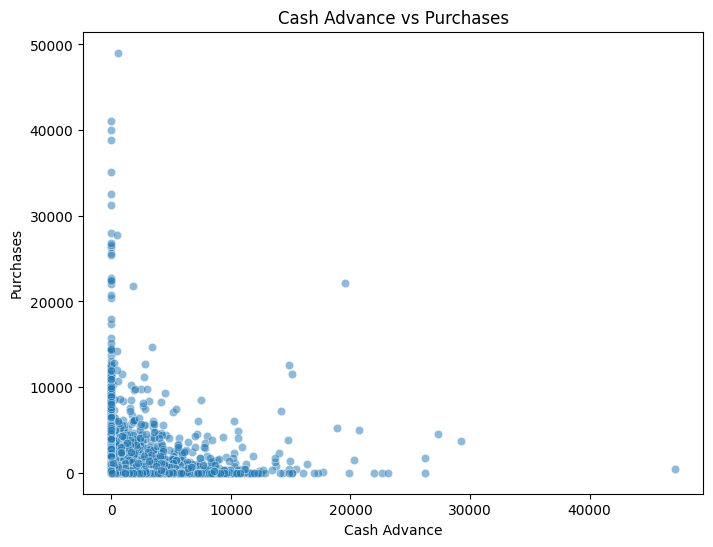

In [10]:
#Cash Advance vs Purchases
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="CASH_ADVANCE",
    y="PURCHASES",
    alpha=0.5
)

plt.title("Cash Advance vs Purchases")
plt.xlabel("Cash Advance")
plt.ylabel("Purchases")
plt.show()

## CORRELATION HEATMAP

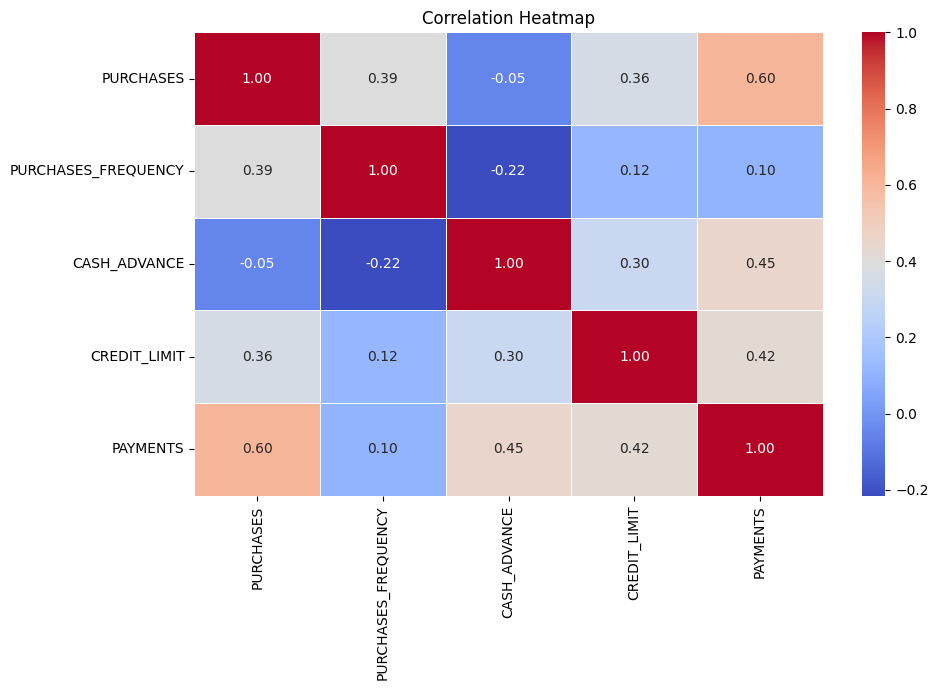

In [11]:
corr_matrix = df[eda_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### FEATURE SELECTION

In [12]:
features = df[[
    "PURCHASES",
    "PURCHASES_FREQUENCY",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS"
]]

### FEATURE SCALING

In [13]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

### FIND OPTIMAL K - ELBOW METHOD

In [14]:
inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

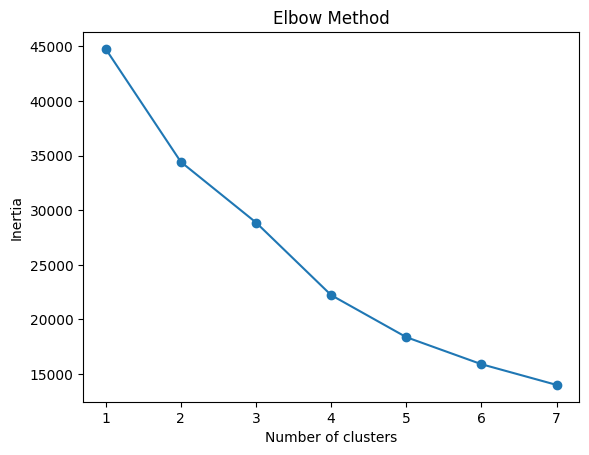

In [15]:
#Plotting the values
plt.plot(range(1, 8), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### APPLY K-MEANS MODEL

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_features)

In [17]:
#Anlayse cluster size
print(df["Cluster"].value_counts())

Cluster
1    6204
0    2580
2     166
Name: count, dtype: int64


### CLUSTER SUMMARY/PROFILING

In [18]:
cluster_summary = df.groupby("Cluster")[[
    "PURCHASES",
    "PURCHASES_FREQUENCY",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS"
]].mean()

print(cluster_summary)

           PURCHASES  PURCHASES_FREQUENCY  CASH_ADVANCE  CREDIT_LIMIT  \
Cluster                                                                 
0        1905.811271             0.695327   1579.338551   8274.667019   
1         423.321278             0.400486    581.664710   2727.705871   
2        8647.017892             0.663124   6491.295985  11762.048193   

             PAYMENTS  
Cluster                
0         2810.751217  
1          884.386197  
2        16705.827533  
